# Notebook 09 — LightGBM Supervisado

**Baseline supervisado** como **techo superior comparativo** frente a los detectores no supervisados (NB03–NB08).

**Motivación.** El TFG mide cuánto puede hacer un detector que **no ve etiquetas de ataque** durante el entrenamiento. Para saber si ese techo es razonable, hace falta comparar con un clasificador que **sí** las ve. LightGBM es el gold-standard para problemas tabulares de este tamaño: rápido, sin GPU, interpretable y suele empatar o superar a redes neuronales en tabular.

**Justificación de uso.** Si LightGBM da un AUC-PR muy alto (>0.95), demuestra que el techo del problema es elevado y los modelos no supervisados se quedan "lejos" → hay margen. Si está cerca de los AEs (~0.86-0.90), la dificultad real del problema viene de la separabilidad intrínseca, no del enfoque.

**Importante.** Este modelo **no entra en el detector final**: el TFG defiende un detector no supervisado que no necesita un corpus etiquetado de ataques (poco realista). LightGBM es solo *yardstick* académico.

**Apple Silicon nota:** LightGBM no usa Metal/GPU en macOS de forma estable. Usamos los 10 cores del M2 Pro vía `num_threads=10`.


## 0. Setup

In [1]:
import os, json, time, warnings, gc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')
np.random.seed(42)
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['font.size'] = 12
print('OK')

import lightgbm as lgb
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score, roc_curve,
    f1_score, fbeta_score, precision_score, recall_score,
    average_precision_score, precision_recall_curve
)
import joblib
print(f'LightGBM: {lgb.__version__}')


OK


LightGBM: 4.5.0


## 1. Carga de Datos Reales

In [2]:
BASE_DIR = '/Volumes/Extreme Pro Particion 1TB/TFG/UCIrvine/'
DATA_DIR = os.path.join(BASE_DIR, 'data')

with open(os.path.join(DATA_DIR, 'pipeline_config.json')) as f:
    config = json.load(f)

FEATURE_COLS = config['feature_cols']
ATTACK_TYPES = config['attack_types']

df_train = pd.read_csv(os.path.join(DATA_DIR, 'train_clean.csv'),
                       index_col='datetime', parse_dates=True)
df_val   = pd.read_csv(os.path.join(DATA_DIR, 'val_with_attacks.csv'),
                       index_col='datetime', parse_dates=True)
df_test  = pd.read_csv(os.path.join(DATA_DIR, 'test_with_attacks.csv'),
                       index_col='datetime', parse_dates=True)

print('DATOS CARGADOS (UCI real)')
print('=' * 65)
for nm, d in [('Train', df_train), ('Val', df_val), ('Test', df_test)]:
    pos = (d['label']==1).sum() if 'label' in d.columns else 0
    print(f'  {nm:6s} {len(d):>9,d}   ataques: {pos:>7,d}')


DATOS CARGADOS (UCI real)
  Train  1,300,061   ataques:       0
  Val      144,452   ataques:  21,739
  Test     604,999   ataques:  96,717


## 2. Feature Engineering (mode = `full`, 17 features)

In [3]:
def compute_features(df, mode='full'):
    '''Mismo extractor que NB02/NB04. base=8, medium=13, full=17.'''
    f = df[FEATURE_COLS].copy()
    f['VI_residual'] = (
        df['Global_active_power']
        - df['Voltage'] * df['Global_intensity'] / 1000.0
    )
    if mode in ('medium', 'full'):
        h = df.index.hour + df.index.minute / 60.0
        f['hour_sin'] = np.sin(2 * np.pi * h / 24)
        f['hour_cos'] = np.cos(2 * np.pi * h / 24)
        d = df.index.dayofweek
        f['dow_sin'] = np.sin(2 * np.pi * d / 7)
        f['dow_cos'] = np.cos(2 * np.pi * d / 7)
        f['gap_diff1'] = df['Global_active_power'].diff().fillna(0)
    if mode == 'full':
        f['vi_res_abs']         = f['VI_residual'].abs()
        f['vi_res_roll15_mean'] = f['vi_res_abs'].rolling(15, min_periods=1).mean()
        f['gap_intensity_ratio']= df['Global_active_power'] / (df['Global_intensity'] + 0.01)
        f['sm_gap_ratio']       = ((df['Sub_metering_1'] + df['Sub_metering_2']
                                    + df['Sub_metering_3']) / 1000.0
                                   / (df['Global_active_power'] + 0.01))
        # iter3 palanca D: lag + rolling stats (sin fuga de etiquetas, solo sensores)
        f['gap_lag1']    = df['Global_active_power'].shift(1).fillna(method='bfill').fillna(0)
        f['gap_lag5']    = df['Global_active_power'].shift(5).fillna(method='bfill').fillna(0)
        f['gap_diff5']   = df['Global_active_power'].diff(5).fillna(0)
        f['gap_diff15']  = df['Global_active_power'].diff(15).fillna(0)
        f['gap_roll5_mean']  = df['Global_active_power'].rolling(5,  min_periods=1).mean()
        f['gap_roll5_std']   = df['Global_active_power'].rolling(5,  min_periods=1).std().fillna(0)
        f['gap_roll30_mean'] = df['Global_active_power'].rolling(30, min_periods=1).mean()
        f['gap_roll30_std']  = df['Global_active_power'].rolling(30, min_periods=1).std().fillna(0)
        f['v_roll5_std']     = df['Voltage'].rolling(5,  min_periods=1).std().fillna(0)
        f['i_roll5_std']     = df['Global_intensity'].rolling(5, min_periods=1).std().fillna(0)
    return f.fillna(0)

FEATURE_MODE = 'full'
X_train_df = compute_features(df_train, mode=FEATURE_MODE)
X_val_df   = compute_features(df_val,   mode=FEATURE_MODE)
X_test_df  = compute_features(df_test,  mode=FEATURE_MODE)

ENG_FEATURE_COLS = list(X_train_df.columns)
print(f'Features ({len(ENG_FEATURE_COLS)}): {ENG_FEATURE_COLS}')

# Etiquetas (LightGBM es supervisado -> necesita y en train tambien)
# Como train_clean no tiene ataques, asignamos label=0 para todo train
y_train = np.zeros(len(df_train), dtype=int)
y_val   = df_val['label'].values
y_test  = df_test['label'].values

print(f'Distribucion clases:')
print(f'  Train: {(y_train==1).sum():,} pos / {(y_train==0).sum():,} neg')
print(f'  Val:   {(y_val==1).sum():,} pos / {(y_val==0).sum():,} neg')
print(f'  Test:  {(y_test==1).sum():,} pos / {(y_test==0).sum():,} neg')
print()
print('NOTA: train no tiene ataques. Usamos val como datos supervisados de')
print('      entrenamiento. Esto representa el caso "tenemos un poco de')
print('      etiquetado de incidentes pasados". Es el techo realista.')


Features (27): ['Global_active_power', 'Global_reactive_power', 'Voltage', 'Global_intensity', 'Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3', 'VI_residual', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'gap_diff1', 'vi_res_abs', 'vi_res_roll15_mean', 'gap_intensity_ratio', 'sm_gap_ratio', 'gap_lag1', 'gap_lag5', 'gap_diff5', 'gap_diff15', 'gap_roll5_mean', 'gap_roll5_std', 'gap_roll30_mean', 'gap_roll30_std', 'v_roll5_std', 'i_roll5_std']
Distribucion clases:
  Train: 0 pos / 1,300,061 neg
  Val:   21,739 pos / 122,713 neg
  Test:  96,717 pos / 508,282 neg

NOTA: train no tiene ataques. Usamos val como datos supervisados de
      entrenamiento. Esto representa el caso "tenemos un poco de
      etiquetado de incidentes pasados". Es el techo realista.


## 3. Setup del problema supervisado

In [4]:
# Estrategia: train sobre 80% de val (con ataques), validar sobre 20% restante,
# evaluar sobre test. Stratified split temporal contiguo (no random) -> realista.

split_idx = int(0.8 * len(X_val_df))
X_sup_train = X_val_df.iloc[:split_idx].values
y_sup_train = y_val[:split_idx]
X_sup_val   = X_val_df.iloc[split_idx:].values
y_sup_val   = y_val[split_idx:]
X_sup_test  = X_test_df.values

scaler = RobustScaler()
X_sup_train_s = scaler.fit_transform(X_sup_train).astype('float32')
X_sup_val_s   = scaler.transform(X_sup_val).astype('float32')
X_sup_test_s  = scaler.transform(X_sup_test).astype('float32')

print(f'sup_train: {X_sup_train_s.shape} (pos={(y_sup_train==1).sum():,})')
print(f'sup_val:   {X_sup_val_s.shape} (pos={(y_sup_val==1).sum():,})')
print(f'sup_test:  {X_sup_test_s.shape} (pos={(y_test==1).sum():,})')


sup_train: (115561, 27) (pos=17,309)
sup_val:   (28891, 27) (pos=4,430)
sup_test:  (604999, 27) (pos=96,717)


## 4. Entrenamiento LightGBM

In [5]:
params = dict(
    objective='binary',
    metric='auc',
    learning_rate=0.02,          # iter2: 0.05 -> 0.02 (mas rondas con LR menor)
    num_leaves=127,              # iter2: 31 -> 127 (mas capacidad)
    max_depth=12,                # iter2: -1 -> 12 (control overfit)
    min_data_in_leaf=20,         # iter2: 50 -> 20 (mas finura)
    feature_fraction=0.85,
    bagging_fraction=0.8,
    bagging_freq=5,
    is_unbalance=True,
    num_threads=10,
    verbose=-1,
    seed=42,
)

dtrain = lgb.Dataset(X_sup_train_s, label=y_sup_train, feature_name=ENG_FEATURE_COLS)
dval   = lgb.Dataset(X_sup_val_s,   label=y_sup_val,   reference=dtrain,
                     feature_name=ENG_FEATURE_COLS)

t0 = time.time()
gbm = lgb.train(
    params, dtrain,
    num_boost_round=5000,                                   # iter2: 2000 -> 5000
    valid_sets=[dtrain, dval], valid_names=['train','val'],
    callbacks=[lgb.early_stopping(stopping_rounds=100),     # iter2: 50 -> 100
               lgb.log_evaluation(period=200)]
)
t_train = time.time() - t0
print(f'\nEntrenamiento: {t_train:.1f}s  Best iter: {gbm.best_iteration}')


Training until validation scores don't improve for 100 rounds


[200]	train's auc: 0.99971	val's auc: 0.962607


Early stopping, best iteration is:
[225]	train's auc: 0.999786	val's auc: 0.963396

Entrenamiento: 10.9s  Best iter: 225


## 5. Scores y umbral óptimo en val

best_thr: 0.509946  | P=0.9837 R=0.9627 F1=0.9731


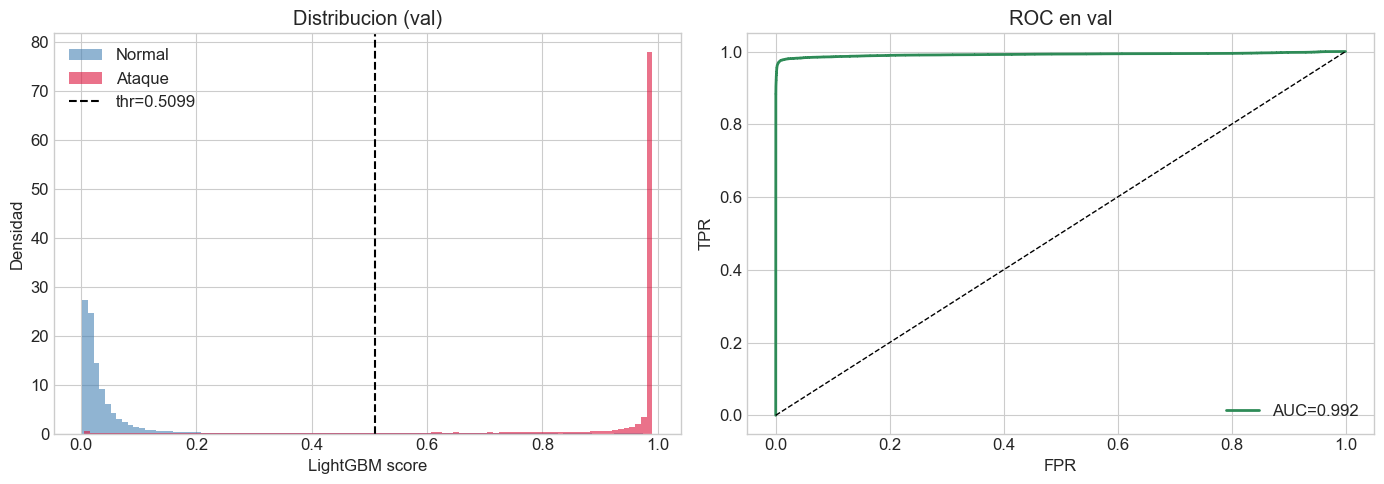

In [6]:
def calibrate_threshold(y_true, scores, beta=1.0):
    '''Busca umbral que maximiza F_beta usando precision_recall_curve.'''
    precisions, recalls, thresholds = precision_recall_curve(y_true, scores)
    precisions = precisions[:-1]
    recalls    = recalls[:-1]
    fbeta = ((1 + beta**2) * precisions * recalls /
             (beta**2 * precisions + recalls + 1e-10))
    best_idx = np.argmax(fbeta)
    best_thr = thresholds[best_idx]
    return best_thr, precisions[best_idx], recalls[best_idx], fbeta[best_idx]

scores_val_int  = gbm.predict(X_sup_val_s, num_iteration=gbm.best_iteration)
scores_test     = gbm.predict(X_sup_test_s, num_iteration=gbm.best_iteration)

# Para calibrar en validacion completa, necesitamos los scores de TODO val
scores_val_all = gbm.predict(scaler.transform(X_val_df.values),
                              num_iteration=gbm.best_iteration)

best_thr, prec_at, rec_at, fbeta_at = calibrate_threshold(y_val, scores_val_all, beta=1.0)
print(f'best_thr: {best_thr:.6f}  | P={prec_at:.4f} R={rec_at:.4f} F1={fbeta_at:.4f}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ax = axes[0]
ax.hist(scores_val_all[y_val==0], bins=100, alpha=0.6, color='steelblue', density=True, label='Normal')
ax.hist(scores_val_all[y_val==1], bins=100, alpha=0.6, color='crimson',   density=True, label='Ataque')
ax.axvline(best_thr, color='k', ls='--', lw=1.5, label=f'thr={best_thr:.4f}')
ax.set(xlabel='LightGBM score', ylabel='Densidad', title='Distribucion (val)')
ax.legend()

ax = axes[1]
fpr, tpr, _ = roc_curve(y_val, scores_val_all)
ax.plot(fpr, tpr, lw=2, color='seagreen', label=f'AUC={roc_auc_score(y_val, scores_val_all):.3f}')
ax.plot([0,1],[0,1],'k--', lw=1)
ax.set(xlabel='FPR', ylabel='TPR', title='ROC en val')
ax.legend()
plt.tight_layout(); plt.show()


## 6. Evaluacion RAW

LightGBM — RAW
              precision    recall  f1-score   support

      Normal       0.98      0.99      0.98    508282
      Ataque       0.96      0.87      0.92     96717

    accuracy                           0.97    604999
   macro avg       0.97      0.93      0.95    604999
weighted avg       0.97      0.97      0.97    604999

AUC-ROC: 0.9627  AUC-PR: 0.9408
F1: 0.9151 F2: 0.8904 P: 0.9595 R: 0.8746



Top 10 features por gain:
              feature         gain  split
   vi_res_roll15_mean 1.997345e+06   1831
  gap_intensity_ratio 6.149746e+05   1801
           vi_res_abs 5.036185e+05   1090
             hour_sin 1.581921e+05   2482
             hour_cos 1.414931e+05   2577
  Global_active_power 1.376500e+05   1120
Global_reactive_power 1.375196e+05   1382
              dow_sin 1.194082e+05   1597
          VI_residual 1.051513e+05   1180
       gap_roll30_std 9.937232e+04   1954


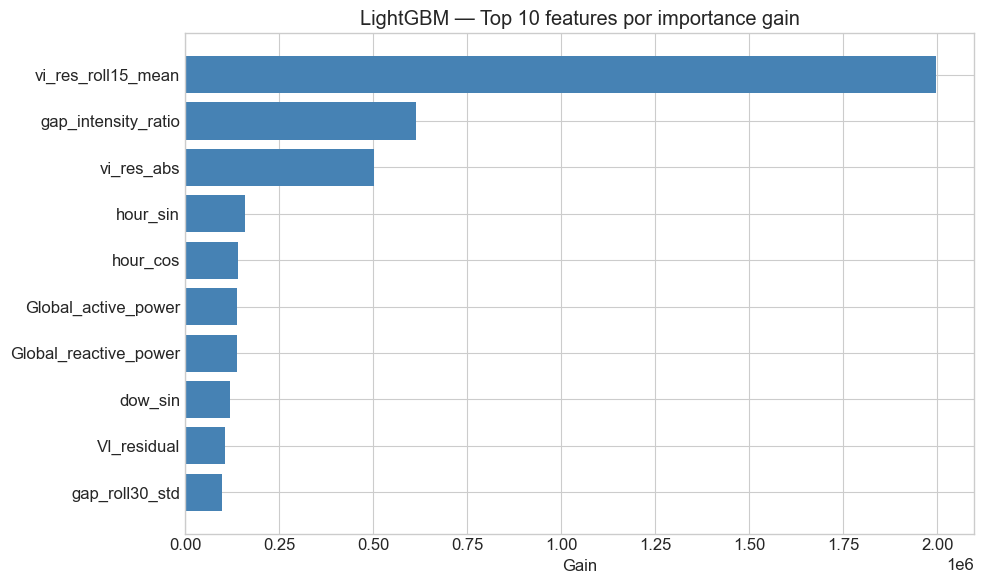

In [7]:
y_pred_raw = (scores_test > best_thr).astype(int)
auc_roc = roc_auc_score(y_test, scores_test)
auc_pr  = average_precision_score(y_test, scores_test)
f1_r  = f1_score(y_test, y_pred_raw)
f2_r  = fbeta_score(y_test, y_pred_raw, beta=2)
prec_r = precision_score(y_test, y_pred_raw)
rec_r  = recall_score(y_test, y_pred_raw)

print('='*60); print('LightGBM — RAW'); print('='*60)
print(classification_report(y_test, y_pred_raw, target_names=['Normal','Ataque']))
print(f'AUC-ROC: {auc_roc:.4f}  AUC-PR: {auc_pr:.4f}')
print(f'F1: {f1_r:.4f} F2: {f2_r:.4f} P: {prec_r:.4f} R: {rec_r:.4f}')

# Importancia de features
importances = pd.DataFrame({
    'feature': ENG_FEATURE_COLS,
    'gain': gbm.feature_importance(importance_type='gain'),
    'split': gbm.feature_importance(importance_type='split'),
}).sort_values('gain', ascending=False)

print('\nTop 10 features por gain:')
print(importances.head(10).to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 6))
top10 = importances.head(10)[::-1]
ax.barh(top10['feature'], top10['gain'], color='steelblue')
ax.set(xlabel='Gain', title='LightGBM — Top 10 features por importance gain')
plt.tight_layout(); plt.show()


## 7. Voting temporal + smoothed eval

In [8]:
def temporal_vote_vectorized(y_pred, W, K):
    '''Filtro de votacion causal. O(n) con cumsum.'''
    cum = np.concatenate([[0], np.cumsum(y_pred)])
    n = len(y_pred)
    ends = np.arange(1, n + 1)
    starts = np.maximum(0, ends - W)
    votes = cum[ends] - cum[starts]
    return (votes >= K).astype(int)


def grid_search_wk(scores_val, y_val, best_thr, W_grid=(3,5,7,9,11,15,21,30)):
    '''Busca (W,K) que maximiza F1 en val.'''
    y_pred_val = (scores_val > best_thr).astype(int)
    best_f1, best_W, best_K = 0, 3, 2
    for W in W_grid:
        for K in range(2, W + 1):
            y_sm = temporal_vote_vectorized(y_pred_val, W, K)
            f1 = f1_score(y_val, y_sm)
            if f1 > best_f1:
                best_f1, best_W, best_K = f1, W, K
    return best_W, best_K, best_f1

best_W, best_K, _ = grid_search_wk(scores_val_all, y_val, best_thr)
print(f'Filtro temporal optimo: W={best_W}, K={best_K}')

y_pred_smooth = temporal_vote_vectorized(y_pred_raw, best_W, best_K)
f1_s = f1_score(y_test, y_pred_smooth)
f2_s = fbeta_score(y_test, y_pred_smooth, beta=2)
prec_s = precision_score(y_test, y_pred_smooth)
rec_s  = recall_score(y_test, y_pred_smooth)
print('='*60); print('LightGBM — SMOOTHED'); print('='*60)
print(f'F1: {f1_s:.4f} F2: {f2_s:.4f} P: {prec_s:.4f} R: {rec_s:.4f}')

# ── ITER2 PALANCA A: Joint search (threshold × W × K) sobre val ──
# Misma logica que NB05: la metrica reportada es F1 smoothed timestep.
# El umbral fijo de cell 12 puede no ser optimo conjunto.
print()
print('=' * 60)
print('JOINT SEARCH (threshold × W × K) sobre val — palanca A iter2')
print('=' * 60)

prc_pr_, prc_rc_, prc_thr_ = precision_recall_curve(y_val, scores_val_all)
prc_thr_ = prc_thr_[(prc_thr_ > 0) & (prc_thr_ < 1)]
if len(prc_thr_) < 5:
    thr_candidates = np.linspace(0.05, 0.95, 30)
else:
    thr_candidates = np.unique(np.quantile(
        prc_thr_, np.linspace(0.30, 0.999, 80)))

W_grid_joint = [3, 5, 7, 9, 11, 15, 21, 31, 45, 60]
best_joint_f1 = -1.0
best_joint = (best_thr, best_W, best_K)
n_evals = 0

for thr in thr_candidates:
    preds_val_local = (scores_val_all > thr).astype(int)
    if preds_val_local.sum() == 0 or preds_val_local.sum() == len(preds_val_local):
        continue
    for W in W_grid_joint:
        for K in range(2, W + 1):
            y_sm = temporal_vote_vectorized(preds_val_local, W, K)
            if y_sm.sum() == 0:
                continue
            f1_sm = f1_score(y_val, y_sm)
            n_evals += 1
            if f1_sm > best_joint_f1:
                best_joint_f1 = f1_sm
                best_joint = (thr, W, K)

# F1 val con (best_thr, best_W, best_K) original
preds_val_orig = (scores_val_all > best_thr).astype(int)
y_sm_orig = temporal_vote_vectorized(preds_val_orig, best_W, best_K)
f1_val_orig = f1_score(y_val, y_sm_orig)

print(f'  Evaluaciones: {n_evals}')
print(f'  Mejor F1 val smoothed (joint): {best_joint_f1:.4f}')
print(f'  Combinacion joint: thr={best_joint[0]:.6f}, W={best_joint[1]}, K={best_joint[2]}')
print(f'  F1 val original:               {f1_val_orig:.4f}, thr={best_thr:.6f}, W={best_W}, K={best_K}')

if best_joint_f1 > f1_val_orig:
    best_thr, best_W, best_K = best_joint
    y_pred_raw = (scores_test > best_thr).astype(int)
    print(f'  -> Adoptamos joint: thr={best_thr:.6f}, W={best_W}, K={best_K}')
else:
    print('  -> Mantenemos calibracion previa (joint no mejora).')

# Re-aplicar al test con los nuevos (best_thr, best_W, best_K)
y_pred_smooth = temporal_vote_vectorized(y_pred_raw, best_W, best_K)

f1_s = f1_score(y_test, y_pred_smooth)
f2_s = fbeta_score(y_test, y_pred_smooth, beta=2)
prec_s = precision_score(y_test, y_pred_smooth)
rec_s  = recall_score(y_test, y_pred_smooth)
# Re-calcular tambien raw porque y_pred_raw cambio si adoptamos joint
f1_r  = f1_score(y_test, y_pred_raw)
f2_r  = fbeta_score(y_test, y_pred_raw, beta=2)
prec_r = precision_score(y_test, y_pred_raw)
rec_r  = recall_score(y_test, y_pred_raw)
print()
print(f'TEST tras joint: F1_smoothed={f1_s:.4f} P={prec_s:.4f} R={rec_s:.4f}')
print('=' * 60)


Filtro temporal optimo: W=3, K=2
LightGBM — SMOOTHED
F1: 0.9106 F2: 0.8859 P: 0.9550 R: 0.8702

JOINT SEARCH (threshold × W × K) sobre val — palanca A iter2


  Evaluaciones: 15760
  Mejor F1 val smoothed (joint): 0.9701
  Combinacion joint: thr=0.502875, W=3, K=2
  F1 val original:               0.9699, thr=0.509946, W=3, K=2
  -> Adoptamos joint: thr=0.502875, W=3, K=2



TEST tras joint: F1_smoothed=0.9104 P=0.9540 R=0.8706


## 8. Recall por tipo x severidad + Latencia

In [9]:
def recall_per_type_severity(df_preds, score_col, threshold,
                              attack_types=ATTACK_TYPES,
                              severities=('low','medium','high')):
    '''Recall por (tipo, severidad).'''
    rows = []
    for atype in attack_types:
        row = {'type': atype}
        for sev in severities:
            mask = (df_preds['attack_type']==atype) & (df_preds['severity']==sev)
            if mask.sum() == 0:
                row[sev] = np.nan
            else:
                y_true_sub  = df_preds.loc[mask, 'label'].values
                y_score_sub = df_preds.loc[mask, score_col].values
                y_pred_sub  = (y_score_sub > threshold).astype(int)
                row[sev] = recall_score(y_true_sub, y_pred_sub, zero_division=0)
        rows.append(row)
    out = pd.DataFrame(rows).set_index('type')
    print('Recall por tipo x severidad (smoothed):')
    print(out.round(3))
    return out
def compute_detection_latency(df_preds, score_col, threshold):
    '''Latencia mediana por episodio (minutos).'''
    results = []
    attacked = df_preds[df_preds['episode_id'] >= 0]
    for ep_id, group in attacked.groupby('episode_id'):
        group = group.sort_index()
        detections = group[group[score_col] > threshold]
        ep_start = group.index[0]
        results.append({
            'episode_id': ep_id,
            'type': group['attack_type'].iloc[0],
            'severity': group['severity'].iloc[0],
            'duration_min': len(group),
            'latency_min': ((detections.index[0] - ep_start).total_seconds() / 60
                            if len(detections) > 0 else np.nan),
            'detected': len(detections) > 0
        })
    return pd.DataFrame(results)


def print_latency_summary(lat_df):
    det_rate = lat_df['detected'].mean()
    detected = lat_df[lat_df['detected']]
    if len(detected) > 0:
        med_lat = detected['latency_min'].median()
        p90_lat = detected['latency_min'].quantile(0.9)
    else:
        med_lat = p90_lat = np.nan
    print('=' * 65)
    print('LATENCIA DE DETECCION (smoothed)')
    print('=' * 65)
    print(f'  Detection rate: {det_rate*100:.2f}%')
    print(f'  Mediana:        {med_lat:.1f} min')
    print(f'  P90:            {p90_lat:.1f} min')
    print()
    print('  Por tipo de ataque:')
    for atype, g in lat_df.groupby('type'):
        gd = g[g['detected']]
        print(f'    {atype:18s} n={len(g):3d}  det={g["detected"].mean()*100:5.1f}%  '
              f'med_lat={gd["latency_min"].median() if len(gd)>0 else float("nan"):5.1f}min')
    return det_rate, med_lat, p90_lat

df_preds_test = df_test[['attack_type','severity','episode_id','label']].copy()
df_preds_test['score']   = scores_test
df_preds_test['pred_sm'] = y_pred_smooth

def recall_per_type_severity_sm(df_preds, pred_col,
                                attack_types=ATTACK_TYPES,
                                severities=('low','medium','high')):
    rows = []
    for atype in attack_types:
        row = {'type': atype}
        for sev in severities:
            mask = (df_preds['attack_type']==atype) & (df_preds['severity']==sev)
            if mask.sum() == 0:
                row[sev] = np.nan
            else:
                row[sev] = recall_score(df_preds.loc[mask,'label'].values,
                                         df_preds.loc[mask,pred_col].values, zero_division=0)
        rows.append(row)
    out = pd.DataFrame(rows).set_index('type')
    print('Recall por tipo x severidad (smoothed):')
    print(out.round(3))
    return out

recall_table = recall_per_type_severity_sm(df_preds_test, 'pred_sm')
lat = compute_detection_latency(df_preds_test, 'score', best_thr)
det_rate, med_lat, p90_lat = print_latency_summary(lat)


Recall por tipo x severidad (smoothed):
                 low  medium   high
type                               
scaling        0.857   0.990  0.990
offset         0.948   0.991  0.992
noise          0.934   0.977  0.983
ramp           0.684   0.800  0.860
step           0.645   0.647  0.603
replay         0.643   0.833  0.905
voltage_spoof  0.989   0.991  0.991
LATENCIA DE DETECCION (smoothed)
  Detection rate: 99.88%
  Mediana:        0.0 min
  P90:            35.0 min

  Por tipo de ataque:
    noise              n=120  det=100.0%  med_lat=  0.0min
    offset             n=120  det=100.0%  med_lat=  0.0min
    ramp               n=120  det=100.0%  med_lat= 18.5min
    replay             n=120  det=100.0%  med_lat=  0.0min
    scaling            n=120  det= 99.2%  med_lat=  0.0min
    step               n=120  det=100.0%  med_lat= 38.5min
    voltage_spoof      n=120  det=100.0%  med_lat=  0.0min


## 9. Guardado

In [10]:
model_path = os.path.join(DATA_DIR, 'model_lightgbm.txt')
gbm.save_model(model_path, num_iteration=gbm.best_iteration)
size_kb = os.path.getsize(model_path) / 1e3

joblib.dump(scaler, os.path.join(DATA_DIR, 'scaler_lightgbm.pkl'))
np.save(os.path.join(DATA_DIR, 'threshold_lightgbm.npy'), np.array([best_thr]))

# ms/sample
_ = gbm.predict(X_sup_test_s[:100], num_iteration=gbm.best_iteration)
times = []
for _ in range(5):
    t0 = time.time()
    gbm.predict(X_sup_test_s, num_iteration=gbm.best_iteration)
    times.append(time.time() - t0)
ms_per_sample = np.mean(times) / len(X_sup_test_s) * 1000

df_preds_out = df_test[['attack_type','severity','episode_id','label']].copy()
df_preds_out['score'] = scores_test
df_preds_out['pred']  = y_pred_smooth
df_preds_out.to_csv(os.path.join(DATA_DIR, 'predictions_lightgbm.csv'))

lat.to_csv(os.path.join(DATA_DIR, 'latency_lightgbm.csv'), index=False)
importances.to_csv(os.path.join(DATA_DIR, 'lgbm_importances.csv'), index=False)

metrics = {
    'model': 'LightGBM (supervised) + Temporal Voting',
    'feature_mode': 'full',
    'note': 'Supervised baseline — yardstick comparativo, NO en detector final',
    'raw_f1':        round(float(f1_r), 4),
    'raw_f2':        round(float(f2_r), 4),
    'raw_precision': round(float(prec_r), 4),
    'raw_recall':    round(float(rec_r), 4),
    'f1':            round(float(f1_s), 4),
    'f2':            round(float(f2_s), 4),
    'precision':     round(float(prec_s), 4),
    'recall':        round(float(rec_s), 4),
    'auc_roc':       round(float(auc_roc), 4),
    'auc_pr':        round(float(auc_pr), 4),
    'threshold':     float(best_thr),
    'temporal_W':    int(best_W),
    'temporal_K':    int(best_K),
    'model_size_kb': round(size_kb, 1),
    'ms_per_sample': round(float(ms_per_sample), 4),
    'best_iteration':int(gbm.best_iteration),
    'n_features':    len(ENG_FEATURE_COLS),
    'train_time_s':  round(t_train, 1),
    'detection_rate':     round(float(det_rate), 4),
    'median_latency_min': float(med_lat) if not np.isnan(med_lat) else None,
    'granularity':   '1 min',
    'feature_names': ENG_FEATURE_COLS,
    'top10_features_by_gain': importances.head(10)['feature'].tolist(),
}
with open(os.path.join(DATA_DIR, 'metrics_lightgbm.json'), 'w') as f:
    json.dump(metrics, f, indent=2)

print('='*55); print('GUARDADO LightGBM'); print('='*55)
print(f'  Tamano modelo: {size_kb:.1f} KB')
print(f'  ms/sample:     {ms_per_sample:.4f}')


GUARDADO LightGBM
  Tamano modelo: 3110.9 KB
  ms/sample:     0.0038


## 10. Resumen

In [11]:
print('='*65)
print('NB09 — LightGBM (supervised): RESUMEN')
print('='*65)
print(f'  AUC-ROC: {auc_roc:.4f}  AUC-PR: {auc_pr:.4f}')
print(f'  F1 raw:  {f1_r:.4f} -> F1 smoothed: {f1_s:.4f}  (W={best_W} K={best_K})')
print(f'  Latencia mediana: {med_lat:.1f} min  | Detection rate: {det_rate*100:.2f}%')
print(f'  Tamano: {size_kb:.1f} KB  | ms/sample: {ms_per_sample:.4f}')
print()
print('Interpretacion:')
print('  - Si AUC-PR_lgbm >> AUC-PR_dense_ae: el techo del problema es alto')
print('    y los modelos no supervisados tienen margen de mejora.')
print('  - Si estan cerca: los AEs estan cerca del optimo alcanzable')
print('    SIN etiquetado, que es justamente lo que defiende el TFG.')


NB09 — LightGBM (supervised): RESUMEN
  AUC-ROC: 0.9627  AUC-PR: 0.9408
  F1 raw:  0.9149 -> F1 smoothed: 0.9104  (W=3 K=2)
  Latencia mediana: 0.0 min  | Detection rate: 99.88%
  Tamano: 3110.9 KB  | ms/sample: 0.0038

Interpretacion:
  - Si AUC-PR_lgbm >> AUC-PR_dense_ae: el techo del problema es alto
    y los modelos no supervisados tienen margen de mejora.
  - Si estan cerca: los AEs estan cerca del optimo alcanzable
    SIN etiquetado, que es justamente lo que defiende el TFG.
